In [2]:
from algorithm.utils.data.tf.fullimage import FullImage
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import sys
import tensorflow as tf
tf.get_logger().setLevel('WARNING')
import keras
import matplotlib.pyplot as plt
import numpy as np
%load_ext tensorboard

In [3]:
regions = FullImage(data_path="../Input/regions")

In [4]:
full_images = regions.get_set()


full_image = full_images[0]

In [5]:
full_image

array([[[ 0.,  2.,  0.],
        [71., 73., 60.],
        [78., 80., 67.],
        ...,
        [76., 78., 65.],
        [76., 78., 65.],
        [76., 78., 65.]],

       [[ 0.,  2.,  0.],
        [71., 73., 60.],
        [78., 80., 67.],
        ...,
        [76., 78., 65.],
        [76., 78., 65.],
        [76., 78., 65.]],

       [[ 0.,  2.,  0.],
        [71., 73., 60.],
        [78., 80., 67.],
        ...,
        [76., 78., 65.],
        [76., 78., 65.],
        [76., 78., 65.]],

       ...,

       [[ 0.,  9.,  0.],
        [39., 62., 46.],
        [36., 59., 43.],
        ...,
        [20., 21., 16.],
        [20., 21., 16.],
        [20., 21., 16.]],

       [[ 0.,  9.,  0.],
        [39., 62., 46.],
        [36., 59., 43.],
        ...,
        [20., 21., 16.],
        [20., 21., 16.],
        [20., 21., 16.]],

       [[ 0.,  9.,  0.],
        [39., 62., 46.],
        [36., 59., 43.],
        ...,
        [20., 21., 16.],
        [20., 21., 16.],
        [20., 21., 16.]]

(-0.5, 6213.5, 4348.5, -0.5)

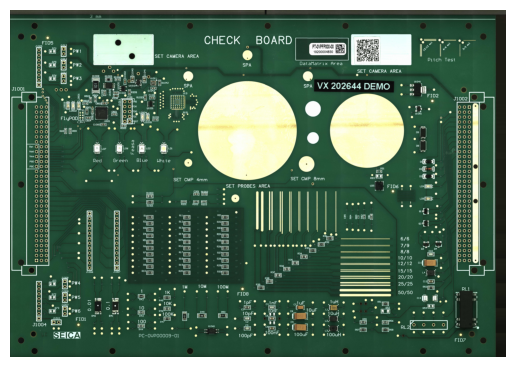

In [6]:
printable_object = regions.print_item(full_image)
plt.imshow(printable_object)
plt.axis('off')  

In [7]:
class_names = regions.labels

In [8]:
class_names

['Ceramic capacitor',
 'Connector',
 'Diode',
 'Dip Switch',
 'Fuse',
 'IC',
 'Inductor',
 'Jumper',
 'Jumper cut',
 'LED',
 'Minimelf',
 'Not mounted',
 'Optoisolator',
 'Oscillator',
 'Pushbutton',
 'Rectangular pin',
 'Relais',
 'Resistor',
 'Resistor Network',
 'SOT',
 'TO252',
 'Tantalum capacitor']

In [9]:
model_dir = "../in/model"
tf.get_logger().setLevel('ERROR')

model = keras.models.load_model(model_dir)

for layer in model.layers:
    if hasattr(layer, 'input_shape'):
        input_shape = layer.input_shape
        break
model__input_shape=input_shape[-3:-1]

resize = False
normalize = True
img_height, img_width = (128, 128) 
mean = [float(1/255), float(1/255), float(1/255)]
num_channels = 3
printable_object = tf.constant("-1", dtype=tf.string)

In [10]:
from algorithm.utils.data.tf.fullimage import sliding_window, preprocess_windows


window_dims = model__input_shape
stride = int(model__input_shape[0]/2)

windows, positions = sliding_window(full_image, window_dims, stride)

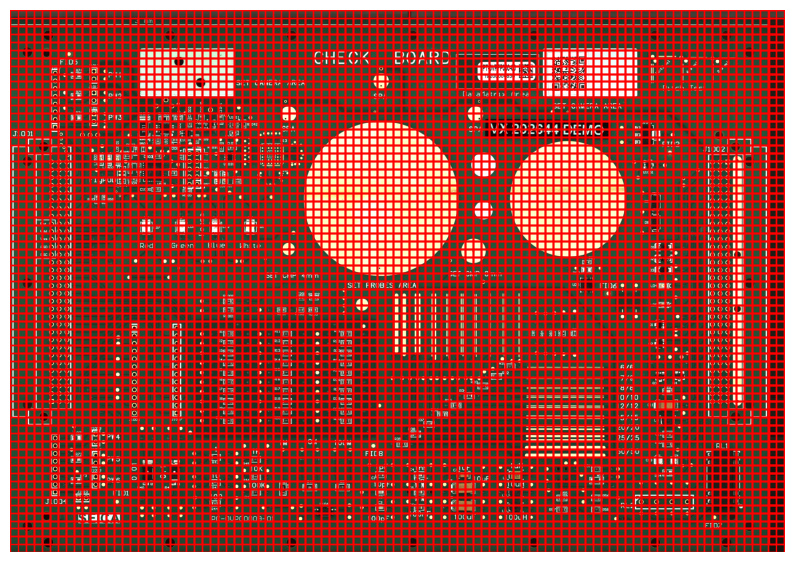

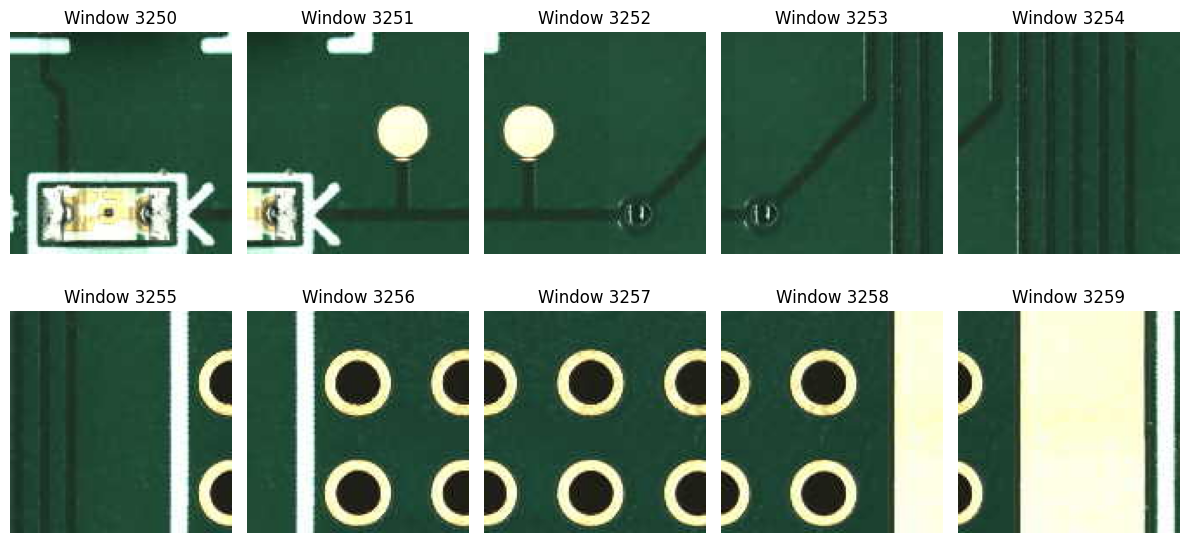

In [11]:
plt.figure(figsize=(10, 10))
plt.imshow(np.uint8(full_image))
plt.axis('off')


for i, (x, y) in enumerate(positions):
    rect = plt.Rectangle((x, y), window_dims[0], window_dims[1], edgecolor='r', facecolor='none')
    plt.gca().add_patch(rect)

plt.show()


plt.figure(figsize=(12, 6))
for i in range(10):
    if i>=10:
        break  
    plt.subplot(2, 5, i + 1)
    plt.imshow(np.uint8(windows[int(len(windows)/2)+i]))
    plt.axis('off')
    plt.title(f'Window {int(len(windows)/2)+i+1}')

plt.tight_layout()
plt.show()

In [12]:
batch_size = 300

batches = preprocess_windows(
                                windows, 
                                positions, 
                                batch_size, 
                                resize=resize, 
                                normalize=normalize, 
                                img_height=img_height, 
                                img_width=img_width, 
                                mean=mean, 
                                printable_object=printable_object
                            )

In [13]:
def classify_windows__batch(batch, model, class_names):
    global counter
    windows_batched, positions_batched = batch
    prediction = model.predict(windows_batched, verbose=0)
    pred_labels = []
    probabilities = []
    for p in prediction:
        sys.stdout.write('\rAnalized window: {}/{}'.format(counter + 1, total_windows))
        sys.stdout.flush()
        counter += 1
        pred_lidx = np.argmax(p)
        pred_labels.append(class_names[pred_lidx])
        probabilities.append(np.max(p))
    return positions_batched, pred_labels, probabilities

In [14]:
from enum import Enum, auto
class Concurrency(Enum):
    Threads = auto()
    Processes = auto()
parallel = True
multiple_reads = True
parallelism = Concurrency.Threads

In [15]:
threshold = 0.6

In [16]:
from functools import partial
import concurrent.futures

counter = 0
total_windows = len(windows)
detections = []
if parallel:
    if parallelism == Concurrency.Threads:
        with concurrent.futures.ThreadPoolExecutor() as executor:
            partial_function = partial(classify_windows__batch, model=model, class_names=class_names)
            results = executor.map(partial_function, batches)
            for batch in results:
                for pos, label, confidence in zip(*batch):
                    if confidence > threshold:
                        detections.append((pos[0], pos[1], window_dims[0], window_dims[0], label, confidence))
    if parallelism == Concurrency.Processes:
        if multiple_reads:  # model is read and loaded from each process
            def classify_windows__batch(batch, model_path, class_names):
                model = keras.models.load_model(model_path)
                global counter
                windows_batched, positions_batched = batch
                prediction = model.predict(windows_batched, verbose=0)
                pred_labels = []
                probabilities = []
                for p in prediction:
                    sys.stdout.write('\rAnalized window: {}/{}'.format(counter + 1, total_windows))
                    sys.stdout.flush()
                    counter += 1
                    pred_lidx = np.argmax(p)
                    pred_labels.append(class_names[pred_lidx])
                    probabilities.append(np.max(p))
                return positions_batched, pred_labels, probabilities
            with concurrent.futures.ProcessPoolExecutor() as executor:
                partial_function = partial(classify_windows__batch, model_path=model_dir, class_names=class_names)
                results = executor.map(partial_function, batches)
                for batch in results:
                    for pos, label, confidence in zip(*batch):
                        if confidence > threshold:
                            detections.append((pos[0], pos[1], window_dims[0], window_dims[0], label, confidence))
        else:   # model is loaded (it has to be serialized before) and shared by each process 
            # model serialization
            from algorithm.deep.tf.neural_networks import ResNet2__0, Branch, Branch_a, Branch_b
            from algorithm.utils.params.tf.dr import DomainRandomization_parameters
            from algorithm.domain_randomization.optimization.tf import (
                r_uniform as r_uniform_opt,
                r_triangular as r_triangular_opt,
                r_univariatenormal as r_univariatenormal_opt,
                r_multivariatenormal as r_multivariatenormal_opt
            )
            from algorithm.domain_randomization.tf import r_uniform, r_triangular, r_univariatenormal, r_multivariatenormal
            from multiprocessing import Manager
            model = keras.models.load_model(
                                        model_dir, 
                                        custom_objects={
                                            "Custom>ResNet2__0": ResNet2__0, 
                                            "Custom>DomainRandomizationParameters": DomainRandomization_parameters,
                                            "Custom>Branch": Branch,
                                            "Custom>Branch_a": Branch_a,
                                            "Custom>Branch_b": Branch_b,
                                            "Custom>RandomInvertoptimizationtfr_multivariatenormallayers": r_multivariatenormal_opt.layers.RandomInvert,
                                            "Custom>Brightnessoptimizationtfr_multivariatenormallayers": r_multivariatenormal_opt.layers.Brightness,
                                            "Custom>Contrastoptimizationtfr_multivariatenormallayers": r_multivariatenormal_opt.layers.Contrast,
                                            "Custom>HorizontallyFlipoptimizationtfr_multivariatenormallayers": r_multivariatenormal_opt.layers.HorizontallyFlip,   
                                            "Custom>VerticallyFlipoptimizationtfr_multivariatenormallayers": r_multivariatenormal_opt.layers.VerticallyFlip,       
                                            "Custom>Hueoptimizationtfr_multivariatenormallayers": r_multivariatenormal_opt.layers.Hue,
                                            "Custom>JpegQualityoptimizationtfr_multivariatenormallayers": r_multivariatenormal_opt.layers.JpegQuality,
                                            "Custom>Saturationoptimizationtfr_multivariatenormallayers": r_multivariatenormal_opt.layers.Saturation,
                                            "Custom>RandomParametersoptimizationtfr_multivariatenormallayers": r_multivariatenormal_opt.layers.RandomParameters,   
                                            "Custom>NoneTransformationoptimizationtfr_multivariatenormallayers": r_multivariatenormal_opt.layers.NoneTransformation,
                                            "Custom>RandomInvertoptimizationtfr_triangularlayers": r_triangular_opt.layers.RandomInvert,
                                            "Custom>RandomBrightnessoptimizationtfr_triangularlayers": r_triangular_opt.layers.RandomBrightness,
                                            "Custom>RandomContrastoptimizationtfr_triangularlayers": r_triangular_opt.layers.RandomContrast,
                                            "Custom>RandomHorizontallyFlipoptimizationtfr_triangularlayers": r_triangular_opt.layers.RandomHorizontallyFlip,       
                                            "Custom>RandomVerticallyFlipoptimizationtfr_triangularlayers": r_triangular_opt.layers.RandomVerticallyFlip,
                                            "Custom>RandomHueoptimizationtfr_triangularlayers": r_triangular_opt.layers.RandomHue,
                                            "Custom>RandomJpegQualityoptimizationtfr_triangularlayers": r_triangular_opt.layers.RandomJpegQuality,
                                            "Custom>RandomSaturationoptimizationtfr_triangularlayers": r_triangular_opt.layers.RandomSaturation,
                                            "Custom>RandomInvertoptimizationtfr_uniformlayers": r_uniform_opt.layers.RandomInvert,
                                            "Custom>RandomBrightnessoptimizationtfr_uniformlayers": r_uniform_opt.layers.RandomBrightness,
                                            "Custom>RandomContrastoptimizationtfr_uniformlayers": r_uniform_opt.layers.RandomContrast,
                                            "Custom>RandomHorizontallyFlipoptimizationtfr_uniformlayers": r_uniform_opt.layers.RandomHorizontallyFlip,
                                            "Custom>RandomVerticallyFlipoptimizationtfr_uniformlayers": r_uniform_opt.layers.RandomVerticallyFlip,
                                            "Custom>RandomHueoptimizationtfr_uniformlayers": r_uniform_opt.layers.RandomHue,
                                            "Custom>RandomJpegQualityoptimizationtfr_uniformlayers": r_uniform_opt.layers.RandomJpegQuality,
                                            "Custom>RandomSaturationoptimizationtfr_uniformlayers": r_uniform_opt.layers.RandomSaturation,
                                            "Custom>RandomInvertoptimizationtfr_univariatenormallayers": r_univariatenormal_opt.layers.RandomInvert,
                                            "Custom>RandomBrightnessoptimizationtfr_univariatenormallayers": r_univariatenormal_opt.layers.RandomBrightness,       
                                            "Custom>RandomContrastoptimizationtfr_univariatenormallayers": r_univariatenormal_opt.layers.RandomContrast,
                                            "Custom>RandomHorizontallyFlipoptimizationtfr_univariatenormallayers": r_univariatenormal_opt.layers.RandomHorizontallyFlip,
                                            "Custom>RandomVerticallyFlipoptimizationtfr_univariatenormallayers": r_univariatenormal_opt.layers.RandomVerticallyFlip,
                                            "Custom>RandomHueoptimizationtfr_univariatenormallayers": r_univariatenormal_opt.layers.RandomHue,
                                            "Custom>RandomJpegQualityoptimizationtfr_univariatenormallayers": r_univariatenormal_opt.layers.RandomJpegQuality,     
                                            "Custom>RandomSaturationoptimizationtfr_univariatenormallayers": r_univariatenormal_opt.layers.RandomSaturation,       
                                            "Custom>RandomInverttfr_multivariatenormallayers": r_multivariatenormal.layers.RandomInvert,
                                            "Custom>Brightnesstfr_multivariatenormallayers": r_multivariatenormal.layers.Brightness,
                                            "Custom>Contrasttfr_multivariatenormallayers": r_multivariatenormal.layers.Contrast,
                                            "Custom>HorizontallyFliptfr_multivariatenormallayers": r_multivariatenormal.layers.HorizontallyFlip,
                                            "Custom>VerticallyFliptfr_multivariatenormallayers": r_multivariatenormal.layers.VerticallyFlip,
                                            "Custom>Huetfr_multivariatenormallayers": r_multivariatenormal.layers.Hue,
                                            "Custom>JpegQualitytfr_multivariatenormallayers": r_multivariatenormal.layers.JpegQuality,
                                            "Custom>Saturationtfr_multivariatenormallayers": r_multivariatenormal.layers.Saturation,
                                            "Custom>RandomParameterstfr_multivariatenormallayers": r_multivariatenormal.layers.RandomParameters,
                                            "Custom>NoneTransformationtfr_multivariatenormallayers": r_multivariatenormal.layers.NoneTransformation,
                                            "Custom>RandomInverttfr_triangularlayers": r_triangular.layers.RandomInvert,
                                            "Custom>RandomBrightnesstfr_triangularlayers": r_triangular.layers.RandomBrightness,
                                            "Custom>RandomContrasttfr_triangularlayers": r_triangular.layers.RandomContrast,
                                            "Custom>RandomHorizontallyFliptfr_triangularlayers": r_triangular.layers.RandomHorizontallyFlip,
                                            "Custom>RandomVerticallyFliptfr_triangularlayers": r_triangular.layers.RandomVerticallyFlip,
                                            "Custom>RandomHuetfr_triangularlayers": r_triangular.layers.RandomHue,
                                            "Custom>RandomJpegQualitytfr_triangularlayers": r_triangular.layers.RandomJpegQuality,
                                            "Custom>RandomSaturationtfr_triangularlayers": r_triangular.layers.RandomSaturation,
                                            "Custom>RandomInverttfr_uniformlayers": r_uniform.layers.RandomInvert,
                                            "Custom>RandomBrightnesstfr_uniformlayers": r_uniform.layers.RandomBrightness,
                                            "Custom>RandomContrasttfr_uniformlayers": r_uniform.layers.RandomContrast,
                                            "Custom>RandomHorizontallyFliptfr_uniformlayers": r_uniform.layers.RandomHorizontallyFlip,
                                            "Custom>RandomVerticallyFliptfr_uniformlayers": r_uniform.layers.RandomVerticallyFlip,
                                            "Custom>RandomHuetfr_uniformlayers": r_uniform.layers.RandomHue,
                                            "Custom>RandomJpegQualitytfr_uniformlayers": r_uniform.layers.RandomJpegQuality,
                                            "Custom>RandomSaturationtfr_uniformlayers": r_uniform.layers.RandomSaturation,
                                            "Custom>RandomInverttfr_univariatenormallayers": r_univariatenormal.layers.RandomInvert,
                                            "Custom>RandomBrightnesstfr_univariatenormallayers": r_univariatenormal.layers.RandomBrightness,
                                            "Custom>RandomContrasttfr_univariatenormallayers": r_univariatenormal.layers.RandomContrast,
                                            "Custom>RandomHorizontallyFliptfr_univariatenormallayers": r_univariatenormal.layers.RandomHorizontallyFlip,
                                            "Custom>RandomVerticallyFliptfr_univariatenormallayers": r_univariatenormal.layers.RandomVerticallyFlip,
                                            "Custom>RandomHuetfr_univariatenormallayers": r_univariatenormal.layers.RandomHue,
                                            "Custom>RandomJpegQualitytfr_univariatenormallayers": r_univariatenormal.layers.RandomJpegQuality,
                                            "Custom>RandomSaturationtfr_univariatenormallayers": r_univariatenormal.layers.RandomSaturation
                                        }
                                      )
            # model sharing
            manager = Manager()
            shared_model = manager.dict()
            shared_model['model'] = model 
            def initializer(shared_model_dict):
                global shared_model
                shared_model = shared_model_dict

            def classify_windows__batch(batch, shared_model, class_names):
                global counter
                model = shared_model['model']
                windows_batched, positions_batched = batch
                prediction = model.predict(windows_batched, verbose=0)
                pred_labels = []
                probabilities = []
                for p in prediction:
                    sys.stdout.write('\rAnalized window: {}/{}'.format(counter + 1, total_windows))
                    sys.stdout.flush()
                    counter += 1
                    pred_lidx = np.argmax(p)
                    pred_labels.append(class_names[pred_lidx])
                    probabilities.append(np.max(p))
                return positions_batched, pred_labels, probabilities
            with concurrent.futures.ProcessPoolExecutor(initializer=initializer, initargs=(shared_model,)) as executor:
                partial_function = partial(classify_windows__batch, shared_model=shared_model, class_names=class_names)
                results = executor.map(partial_function, batches)
                for batch in results:
                    for pos, label, confidence in zip(*batch):
                        if confidence > threshold:
                            detections.append((pos[0], pos[1], window_dims[0], window_dims[0], label, confidence))
else:
    results = [classify_windows__batch(batch, model=model, class_names=class_names) for batch in batches]
    for batch in results:
        for pos, label, confidence in zip(*batch):
            if confidence > threshold:
                detections.append((pos[0], pos[1], window_dims[0], window_dims[0], label, confidence))

Analized window: 6498/6498

In [17]:
print("\n")
for (x, y, w, h, label, confidence) in detections:
    print(f"Object detected: {label} with confidence {confidence} at ({x}, {y}, {w}, {h})")



Object detected: Resistor with confidence 0.6898533701896667 at (0, 0, 128, 128)
Object detected: Connector with confidence 0.8751855492591858 at (64, 0, 128, 128)
Object detected: Connector with confidence 0.9815807938575745 at (128, 0, 128, 128)
Object detected: Connector with confidence 0.9336545467376709 at (192, 0, 128, 128)
Object detected: Connector with confidence 0.9713862538337708 at (256, 0, 128, 128)
Object detected: Connector with confidence 0.8107444047927856 at (320, 0, 128, 128)
Object detected: Connector with confidence 0.7473675608634949 at (384, 0, 128, 128)
Object detected: Resistor with confidence 0.638140082359314 at (512, 0, 128, 128)
Object detected: Connector with confidence 0.7714310884475708 at (576, 0, 128, 128)
Object detected: Connector with confidence 0.8371710777282715 at (640, 0, 128, 128)
Object detected: Connector with confidence 0.7166592478752136 at (704, 0, 128, 128)
Object detected: Connector with confidence 0.6046249866485596 at (768, 0, 128, 1

In [19]:
import numpy as np
# Non maximum suppression
def non_maximum_suppression(detections, iou_threshold=0.5):
    if len(detections) == 0:
        return []

    # detections ordered in terms of confidencen score
    detections = sorted(detections, key=lambda x: x[5], reverse=True)
    nms_detections = []

    while detections:
        # Select detection with the highest confidence score
        best_detection = detections.pop(0)
        nms_detections.append(best_detection)
        
        remaining_detections = []
        
        for det in detections:
            if iou(best_detection, det) < iou_threshold:
                remaining_detections.append(det)
        
        detections = remaining_detections

    return nms_detections

# Compute Intersection over Union (IoU)
def iou(box1, box2):
    x1, y1, w1, h1 = box1[:4]
    x2, y2, w2, h2 = box2[:4]
    
    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1 + w1, x2 + w2)
    yi2 = min(y1 + h1, y2 + h2)
    
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = w1 * h1
    box2_area = w2 * h2
    
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area if union_area != 0 else 0

In [25]:
iou_threshold = 0.5

In [26]:
nms_detections = non_maximum_suppression(detections, iou_threshold)

In [22]:
for (x, y, w, h, label, confidence) in detections:
    print(f"Object detected: {label} with confidence {confidence} at ({x}, {y}, {w}, {h})")



Object detected: Resistor with confidence 0.6898533701896667 at (0, 0, 128, 128)
Object detected: Connector with confidence 0.8751855492591858 at (64, 0, 128, 128)
Object detected: Connector with confidence 0.9815807938575745 at (128, 0, 128, 128)
Object detected: Connector with confidence 0.9336545467376709 at (192, 0, 128, 128)
Object detected: Connector with confidence 0.9713862538337708 at (256, 0, 128, 128)
Object detected: Connector with confidence 0.8107444047927856 at (320, 0, 128, 128)
Object detected: Connector with confidence 0.7473675608634949 at (384, 0, 128, 128)
Object detected: Resistor with confidence 0.638140082359314 at (512, 0, 128, 128)
Object detected: Connector with confidence 0.7714310884475708 at (576, 0, 128, 128)
Object detected: Connector with confidence 0.8371710777282715 at (640, 0, 128, 128)
Object detected: Connector with confidence 0.7166592478752136 at (704, 0, 128, 128)
Object detected: Connector with confidence 0.6046249866485596 at (768, 0, 128, 128

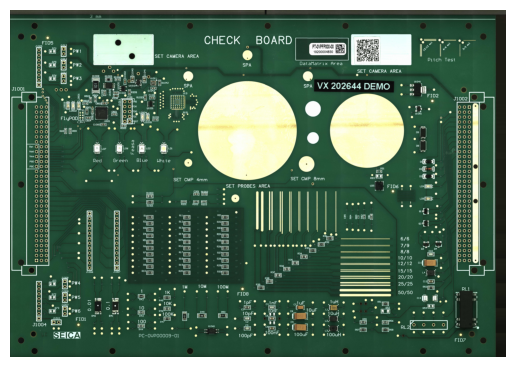

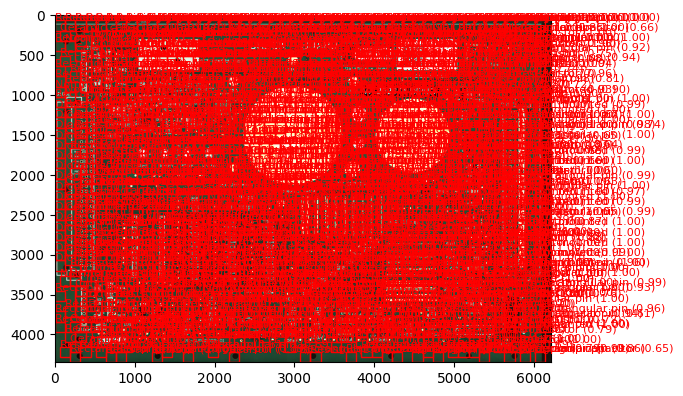

In [34]:
plt.imshow(np.uint8(full_image))
plt.axis('off')

def plot_detections(image, detections):
    fig, ax = plt.subplots(1)
    ax.imshow(image.astype(np.uint8))
    for (x, y, w, h, label, confidence) in nms_detections:
        rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)
        plt.text(x, y, f'{label} ({confidence:.2f})', color='r', fontsize=8)

    plt.show()


plot_detections(full_image, nms_detections)

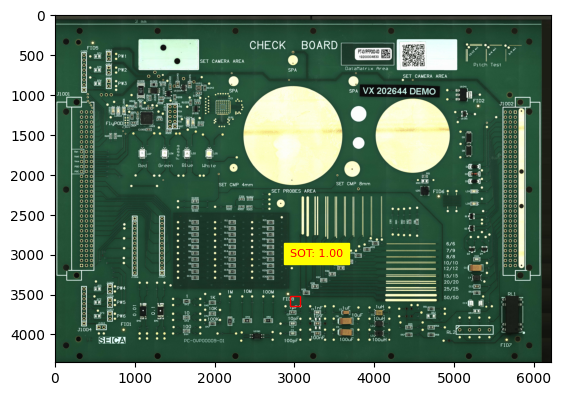

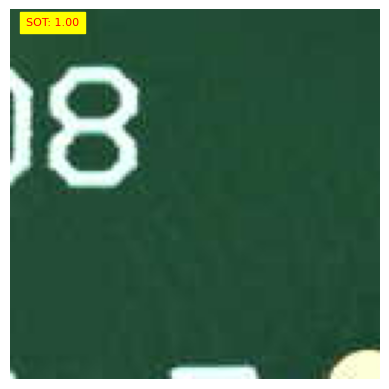

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_single_detection(image, detection, label_offset=(0, -500)):
    x, y, w, h, label, confidence = detection
    
    fig, ax = plt.subplots(1)
    ax.imshow(image.astype(np.uint8))
    
    rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    
    label_x = x + label_offset[0]
    label_y = y + label_offset[1]
    
    plt.text(label_x, label_y, f"{label}: {confidence:.2f}", color='red', fontsize=8, backgroundcolor='yellow')
    
    plt.show()

def plot_single_detection__alone(image, detection):
    x, y, w, h, label, confidence = detection
    
    bounding_box = image[y:y+h, x:x+w]
    
    fig, ax = plt.subplots(1)
    ax.imshow(bounding_box.astype(np.uint8))
    
    plt.text(5, 5, f"{label}: {confidence:.2f}", color='red', fontsize=8, backgroundcolor='yellow')
    
    plt.axis('off')  
    plt.show()

plot_single_detection(full_image, nms_detections[614])
plot_single_detection__alone(full_image, nms_detections[614])

In [57]:
def add_centroid(detection):
    x, y, w, h, label, confidence = detection

    x2, y2 = x + w, y + h
 
    centroid_x = (x + x2) / 2
    centroid_y = (y + y2) / 2
    
    detection_with_centroid = (x, y, w, h, centroid_x, centroid_y, label, confidence)
    
    return detection_with_centroid

In [58]:
nms_detections = [add_centroid(nms) for nms in nms_detections]